In [4]:
import pandas as pd
# import sys
# print(sys.executable)
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("/Users/katelandsipe/Documents/Research/git/viral_tax_dataset/vmr_msl40_v2_20251013_proteins_taxonomy_final_clean.csv")
print(df.head())

/var/folders/f5/ydxpbz690zv37t08r12ss25r0000gn/T/ipykernel_83660/1996580054.py:1: DtypeWarning: Columns (3,5,7,8,11,12,13,14,16,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/katelandsipe/Documents/Research/git/viral_tax_dataset/vmr_msl40_v2_20251013_proteins_taxonomy_final_clean.csv")


   Isolate ID  Species Sort  Isolate Sort      Realm  Subrealm      Kingdom  \
0  VMR1028127             1             1  Adnaviria       NaN  Zilligvirae   
1  VMR1028127             1             1  Adnaviria       NaN  Zilligvirae   
2  VMR1028127             1             1  Adnaviria       NaN  Zilligvirae   
3  VMR1028127             1             1  Adnaviria       NaN  Zilligvirae   
4  VMR1028127             1             1  Adnaviria       NaN  Zilligvirae   

   Subkingdom         Phylum Subphylum          Class  ...  \
0         NaN  Taleaviricota       NaN  Tokiviricetes  ...   
1         NaN  Taleaviricota       NaN  Tokiviricetes  ...   
2         NaN  Taleaviricota       NaN  Tokiviricetes  ...   
3         NaN  Taleaviricota       NaN  Tokiviricetes  ...   
4         NaN  Taleaviricota       NaN  Tokiviricetes  ...   

                                    Protein Sequence accession_clean  \
0  MITTTRRGYIKVPPLQRERATAIMLYRAGQSINNIALFLGRSTSWV...        PP467602   
1  MVYPH

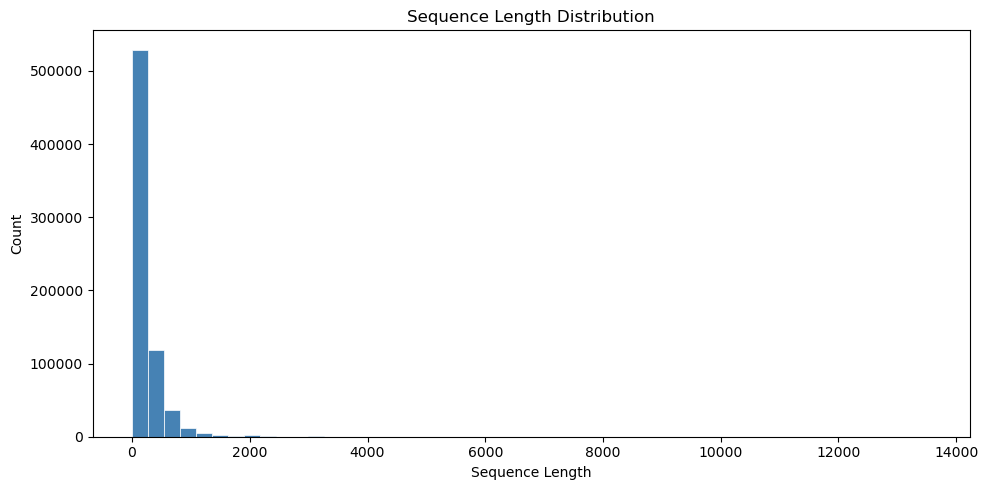

In [26]:
df["seq_len"] = df["prot_seq"].str.len()
plt.figure(figsize=(10, 5))
plt.hist(df['seq_len'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title('Sequence Length Distribution')
plt.tight_layout()
plt.savefig('/Users/katelandsipe/Documents/Research/git/viral_tax_dataset/seq_len_distribution')
plt.show()

In [29]:
threshold = df['seq_len'].quantile(0.999)

df_filtered = df[df['seq_len'] <= threshold]
df_outliers = df[df['seq_len'] > threshold]
print(df_outliers.shape)
print(len(df_outliers['Isolate ID'].unique()))
print(df_outliers['Realm'].unique())

(710, 45)
670
['Duplodnaviria' 'Riboviria' 'Varidnaviria' nan]


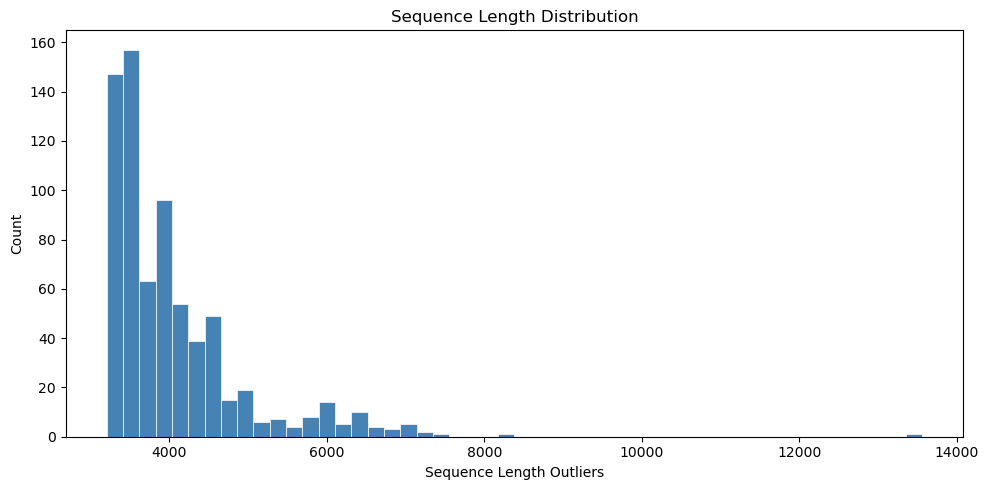

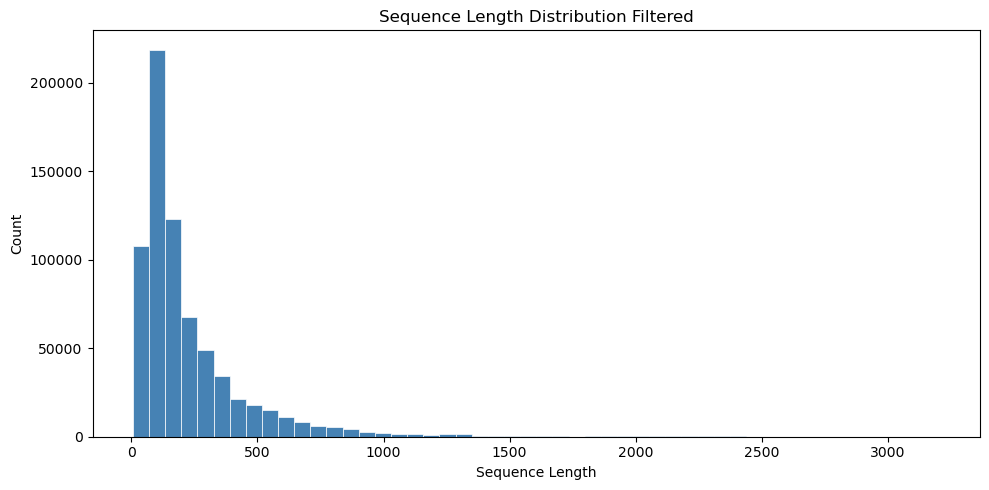

In [31]:

plt.figure(figsize=(10, 5))
plt.hist(df_outliers['seq_len'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
plt.xlabel('Sequence Length Outliers')
plt.ylabel('Count')
plt.title('Sequence Length Distribution')
plt.tight_layout()
plt.savefig('/Users/katelandsipe/Documents/Research/git/viral_tax_dataset/seq_len_distribution_outliers')
plt.show()


plt.figure(figsize=(10, 5))
plt.hist(df_filtered['seq_len'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title('Sequence Length Distribution Filtered')
plt.tight_layout()
plt.savefig('/Users/katelandsipe/Documents/Research/git/viral_tax_dataset/seq_len_distribution_filtered')
plt.show()

In [33]:
print(df.columns)

Index(['Isolate ID', 'Species Sort', 'Isolate Sort', 'Realm', 'Subrealm',
       'Kingdom', 'Subkingdom', 'Phylum', 'Subphylum', 'Class', 'Subclass',
       'Order', 'Suborder', 'Family', 'Subfamily', 'Genus', 'Subgenus',
       'Species', 'ICTV_ID', 'Exemplar or additional isolate', 'Virus name(s)',
       'Virus name abbreviation(s)', 'Virus isolate designation',
       'Virus GENBANK accession', 'Genome coverage', 'Genome', 'Host source',
       'Accessions Link', 'accession', 'coords', 'Accession ID', 'Seq Length',
       'Location', 'Protein ID', 'Protein Sequence', 'accession_clean',
       'genome_start', 'genome_end', 'filtered_protein', 'prot_start',
       'prot_end', 'strand', 'prot_str', 'prot_seq', 'seq_len'],
      dtype='object')


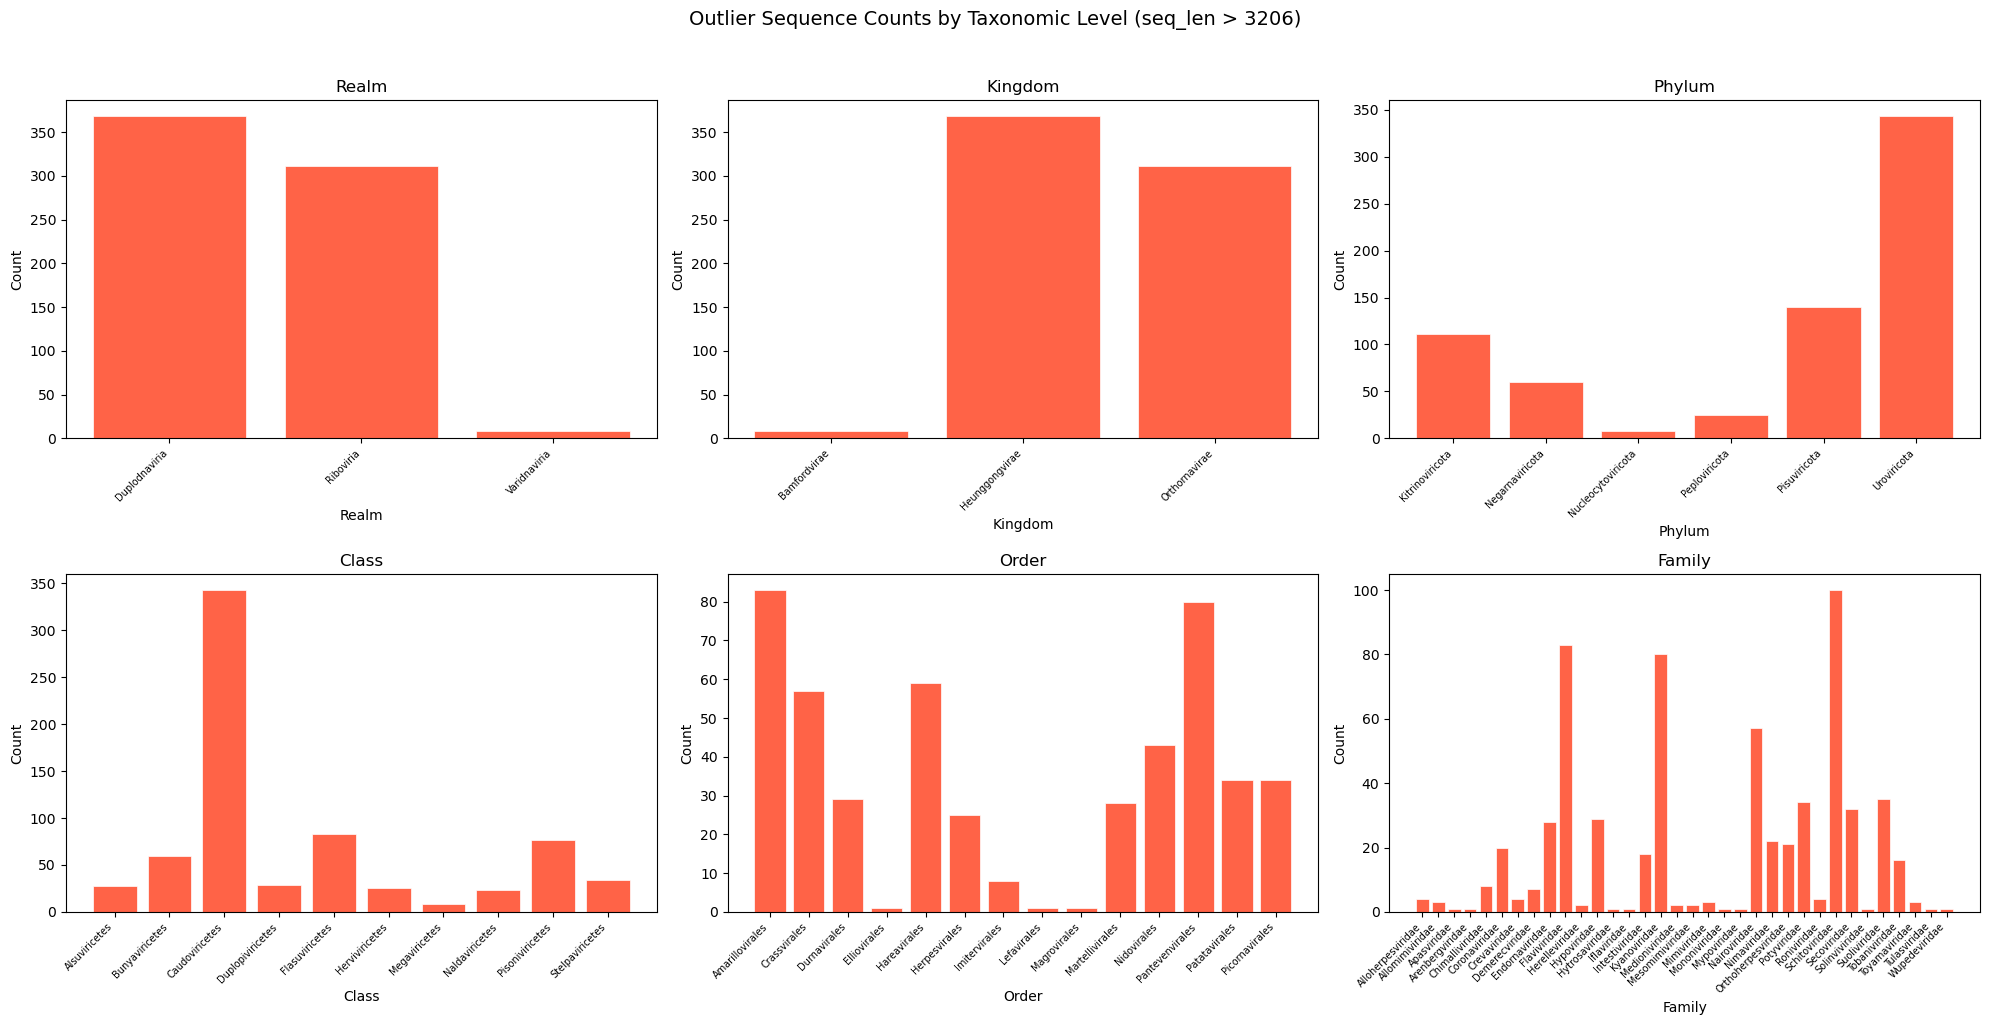

In [38]:
tax_cols = ['Realm', 'Kingdom', 'Phylum', 'Class', 'Order', 'Family']
fig, axes = plt.subplots(2, 3, figsize=(20,10))
axes = axes.flatten()
for i, col in enumerate(tax_cols):
    ax = axes[i]
    counts = df_outliers[col].value_counts().sort_index()
    ax.bar(range(len(counts)), counts.values, color='tomato', edgecolor='white', linewidth=0.5)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Outlier Sequence Counts by Taxonomic Level (seq_len > {threshold:.0f})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/Users/katelandsipe/Documents/Research/git/viral_tax_dataset/Outlier_Sequence_cnt_by_rank')
plt.show()